In [1]:
!nvidia-smi


Sat Aug 22 18:34:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [3]:
! pip install -Uqq fastai nbdev fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.2 MB/s eta 0:00:00


In [4]:
from fastai.text.all import *

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/udemy_project/Text Classification with fastai and ULMFit

/content/drive/MyDrive/udemy_project/Text Classification with fastai and ULMFit


#Data

In [7]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/udemy_project/Datasets/course_details.csv")
df.head(5)

,title,url,description,topic,topic_list
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']"
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']"
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']"
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']"
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Languages', 'React JS', 'React Hooks']"


In [8]:
df.shape

(11061, 5)

In [9]:
df.isna().sum()

,0
title,0
url,0
description,4
topic,4
topic_list,0


In [10]:
df = df.dropna().reset_index(drop=True)

In [11]:
topic_list = []
indices_to_drop = []
for idx, topics in enumerate(df.topic_list.to_list()):
  topics_list = eval(topics)
  if len(topics_list):
    topic_list.append(topics_list[0])
  else:
    indices_to_drop.append(idx)

df = df.drop(indices_to_drop).reset_index(drop=True)
df.shape

(11057, 5)

In [12]:
df['primary_topic'] = topic_list

In [14]:
df['primary_topic'].value_counts()

,count
primary_topic,
Development,1597
Finance & Accounting,1586
Marketing,1583
Business,1583
Personal Development,1577
IT & Software,1561
Design,1554
Udemy Free Resource Center,13
Vodafone,2


### Removing rare subcategory


In [15]:
topic_count = df['primary_topic'].value_counts()
threshold = int(len(df) * 0.005)
rare_topics = [cat for cat, count in topic_count.items() if count < threshold]
len(rare_topics), rare_topics[:5]

(3, ['Udemy Free Resource Center', 'Vodafone', 'Health & Fitness'])

In [16]:
rare_indices_to_drop = [idx for idx, row in df.iterrows() if row['primary_topic'] in rare_topics]
len(rare_indices_to_drop)

16

In [17]:
df = df.drop(rare_indices_to_drop).reset_index(drop=True)
df.shape

(11041, 6)

In [18]:
df['primary_topic'].value_counts()

,count
primary_topic,
Development,1597
Finance & Accounting,1586
Business,1583
Marketing,1583
Personal Development,1577
IT & Software,1561
Design,1554


In [19]:
len(df['primary_topic'].value_counts())

7

In [20]:
df.describe(include='object')

,title,url,description,topic,topic_list,primary_topic
count,11041,11041,11041,11041,11041,11041
unique,11021,11041,11033,1959,8303,7
top,HTML & CSS - Certification Course for Beginners,https://www.udemy.com/course/professional-ethics-for-helping-professions,"We live in an instant gratification culture today. So everyone (especially everyone on Instagram) expects things overnight. But the reality is growth won't come from a ""lucky"" post that goes viral...no matter how many people tell you that you just need to hit the explore page & then you too can be ""Instagram famous."" People like that want you to believe they have the ""secret"" to growth so they can sell you on their expertise & products. But anyone who's ACTUALLY grown on Instagram (or anywhere for that matter) understands that it doesn't happen overnight or by some stroke of luck. You w...",Python,"['Development', 'Programming Languages', 'Python']",Development
freq,2,1,3,133,47,1597


In [21]:
df.head()

,title,url,description,topic,topic_list,primary_topic
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']",Development
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']",Development
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']",Development
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']",Development
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Lang

## DataLoaders

In [22]:
doc(RandomSplitter)

In [23]:
dls = TextDataLoaders.from_df(df,
                                 text_col='description',
                                 label_col='primary_topic',
                                 bs=16,
                                 seq_len=512,
                                 splitter = RandomSplitter(valid_pct=0.1, seed=42))

In [24]:
dls.vocab[0]

['xxunk',
 'xxpad',
 'xxbos',
 'xxeos',
 'xxfld',
 'xxrep',
 'xxwrep',
 'xxup',
 'xxmaj',
 ',',
 '.',
 'and',
 'to',
 'the',
 'you',
 'of',
 'a',
 '-',
 'in',
 'course',
 'this',
 'your',
 'is',
 'for',
 'with',
 'will',
 'how',
 ':',
 'that',
 'i',
 'on',
 'it',
 'are',
 'learn',
 '!',
 'as',
 ')',
 'can',
 'we',
 'or',
 'have',
 '(',
 'from',
 'be',
 'by',
 '"',
 'what',
 '?',
 'an',
 'more',
 'all',
 'do',
 'use',
 "'s",
 'get',
 'business',
 'using',
 'not',
 'data',
 'if',
 'about',
 'so',
 '&',
 'create',
 "'ll",
 'my',
 'at',
 'skills',
 'also',
 'into',
 'learning',
 'step',
 'marketing',
 'time',
 'but',
 'who',
 'help',
 'management',
 'ai',
 'work',
 'make',
 'like',
 'need',
 'real',
 'their',
 'understand',
 'up',
 'design',
 'world',
 'most',
 '3',
 'new',
 'one',
 'want',
 'our',
 'tools',
 'take',
 'through',
 '/',
 'content',
 'any',
 'section',
 'build',
 'knowledge',
 'no',
 'just',
 'start',
 'know',
 'experience',
 'students',
 'life',
 'way',
 'these',
 'understan

In [25]:
dls.vocab[1]

['Business', 'Design', 'Development', 'Finance & Accounting', 'IT & Software', 'Marketing', 'Personal Development']

In [26]:
dls.show_batch(max_n=3)

,text,category
0,"xxbos xxmaj memory xxmaj improvement xxmaj training xxmaj course – xxmaj the xxmaj most xxmaj comprehensive xxmaj memory xxmaj masterclass xxmaj you 'll xxmaj ever xxmaj need . xxmaj never xxmaj forget xxmaj again xxmaj learn xxmaj to xxmaj unlock the xxmaj power of xxmaj your xxmaj mind with xxmaj memory xxmaj master & xxmaj expert , xxmaj sancy . xxmaj have you ever wished you could remember names , numbers , facts , vocabulary , or even entire presentations with flawless accuracy ? xxmaj imagine walking into a room and effortlessly recalling every name and face , delivering a powerful speech without a single note , or sitting for an important exam and having every key concept instantly at your mental fingertips . xxmaj with the right training , these smart memory feats are n’t just possible — xxunk repeatable . xxmaj in this transformational memorization course , you",Personal Development
1,"xxbos xxmaj the xxmaj ultimate xxmaj digital xxmaj advertising xxmaj course + chatgpt xxmaj guide : xxmaj from xxmaj foundations to xxmaj advanced xxup ai xxmaj strategies xxmaj dive into the expansive world of digital advertising with our comprehensive course , meticulously designed to arm you with the mastery of not just traditional advertising platforms , but also the cutting - edge integration of xxup ai technologies like chatgpt and xxmaj google xxup ai . xxmaj this all - encompassing guide is tailored to offer a deep dive into the realms of xxmaj google xxmaj ads , youtube xxmaj ads , xxmaj gmail xxmaj ads , xxmaj bing xxmaj ads , xxmaj facebook xxmaj ads , xxmaj instagram xxmaj ads , xxmaj messenger xxmaj ads , xxmaj dynamic xxmaj ads , xxmaj retargeting xxmaj ads , re - engagement xxmaj ads , and the strategic use of chatgpt for advertising",Marketing
2,"xxbos xxup updated xxup for xxup spring xxup boot 4 xxup and xxup spring 7 xxup popular xxup ide - intellij ( free version ) # 1 xxup best xxup selling xxup spring xxup boot & xxup hibernate xxup course xxup on xxup udemy - 440 , xxrep 3 0 + xxup students xxup enrolled xxup this xxup course xxup has xxup the # 1 xxup student xxup enrollment xxup of xxup any xxup spring xxup boot xxup course xxup on xxup udemy ! xxup over 92 , xxrep 3 0 xxup reviews - 5 xxup stars ! xxup this xxup course xxup covers xxup spring xxup boot 4 xxup and xxup spring 7 xxup learn these xxup hot xxup topics in xxmaj spring xxmaj boot 4 and xxmaj spring 7 : xxmaj spring xxmaj boot 4 xxmaj spring xxmaj framework 7 xxmaj spring xxmaj boot 4 xxup rest xxup",Development


In [27]:
torch.save(dls, "dataloaders/dls_text_clas.pkl")

In [ ]:
# dls = torch.load("dataloaders/dls_text_clas.pkl")

# Modeling

In [28]:
doc(text_classifier_learner)

In [29]:
learner = text_classifier_learner(dls,
                                AWD_LSTM,
                                drop_mult=0.5,
                                metrics=accuracy).to_fp16()

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:03&lt;00:00]</div>

In [30]:
learner.model

SequentialRNN(
  (0): SentenceEncoder(
    (module): AWD_LSTM(
      (encoder): Embedding(23784, 400, padding_idx=1)
      (encoder_dp): EmbeddingDropout(
        (emb): Embedding(23784, 400, padding_idx=1)
      )
      (rnns): ModuleList(
        (0): WeightDropout(
          (module): LSTM(400, 1152, batch_first=True)
        )
        (1): WeightDropout(
          (module): LSTM(1152, 1152, batch_first=True)
        )
        (2): WeightDropout(
          (module): LSTM(1152, 400, batch_first=True)
        )
      )
      (input_dp): RNNDropout()
      (hidden_dps): ModuleList(
        (0-2): 3 x RNNDropout()
      )
    )
  )
  (1): PoolingLinearClassifier(
    (layers): Sequential(
      (0): LinBnDrop(
        (0): BatchNorm1d(1200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Dropout(p=0.2, inplace=False)
        (2): Linear(in_features=1200, out_features=50, bias=False)
        (3): ReLU(inplace=True)
      )
      (1): LinBnDrop(
        (0): B

In [31]:
learner = learner.load_encoder('lm-encoder-finetuned')

## Stage - 0

In [39]:
learner.freeze()

<div></div>

SuggestedLRs(slide=0.0014454397605732083, valley=0.0008317637839354575)

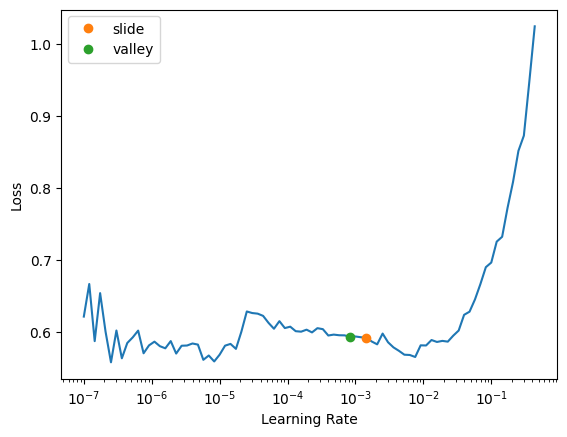

In [40]:
learner.lr_find(suggest_funcs=(slide, valley))

In [41]:
learner.fit_one_cycle(1, 8e-4)

epoch,train_loss,valid_loss,accuracy,time
0,0.613996,0.499139,0.830616,01:38


In [42]:
learner.save("course-classifier-stage-0")

Path('models/course-classifier-stage-0.pth')

## Stage - 1

In [43]:
learner.freeze_to(-2)

<div></div>

SuggestedLRs(slide=0.0010000000474974513, valley=0.0003981071640737355)

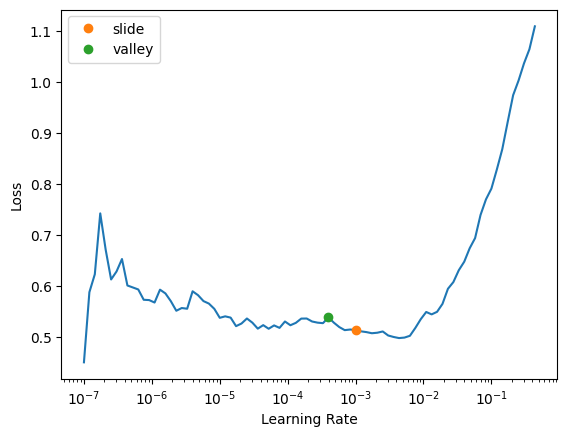

In [44]:
learner.lr_find(suggest_funcs=(slide, valley))

In [45]:
learner.fit_one_cycle(1, 4e-4)

epoch,train_loss,valid_loss,accuracy,time
0,0.583439,0.498603,0.825634,01:52


In [46]:
learner.save("course-classifier-stage-1")

Path('models/course-classifier-stage-1.pth')

## Stage - 2

In [47]:
learner.freeze_to(-3)

<div></div>

SuggestedLRs(slide=0.0002754228771664202, valley=2.0892961401841603e-05)

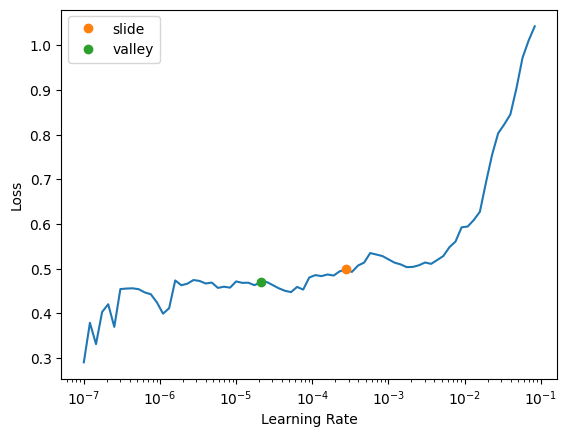

In [48]:
learner.lr_find(suggest_funcs=(slide, valley))

In [49]:
learner.fit_one_cycle(1, 2e-5)

epoch,train_loss,valid_loss,accuracy,time
0,0.552852,0.482661,0.829257,02:30


In [50]:
learner.save("course-classifier-stage-2")

Path('models/course-classifier-stage-2.pth')

##Stage-03

In [51]:
learner.unfreeze()

<div></div>

SuggestedLRs(slide=0.0006918309954926372, valley=0.00015848931798245758)

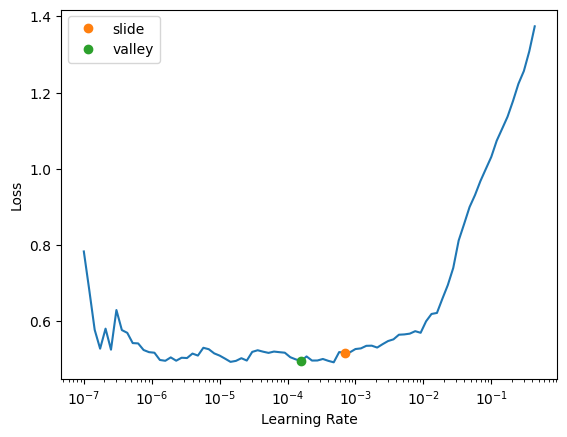

In [52]:
learner.lr_find(suggest_funcs=(slide, valley))

In [53]:
learner.fit_one_cycle(5, slice(1e-5, 1.6e-4))

epoch,train_loss,valid_loss,accuracy,time
0,0.516449,0.476735,0.834692,03:11
1,0.555286,0.461547,0.836051,03:11
2,0.525462,0.467894,0.839221,03:10
3,0.458694,0.457180,0.838315,03:11
4,0.453918,0.459902,0.841033,03:11


In [54]:
learner.save("course-classifier-stage-3")

Path('models/course-classifier-stage-3.pth')